## Graph-based multimodal integration with CITE-seq data

In this notbook we'll attempt a Weighted Nearest Neighbor (WNN)-joint modality analysis by integrating 10X Genomics' PBMC10k and PBMC5k datasets of peripheral blood mononuclear cells, specifically subset to the 17 shared proteins between them ([source](https://docs.scvi-tools.org/en/stable/tutorials/notebooks/use_cases/preprocessing.html#cite-seq)). This workflow mirrors a typical CITE-seq analysis aimed towards connecting transcriptional variation with cell phenotype and function.

For brevity--and to support a methods-based focus--extensive QC is not performed here, but standard approaches for both RNA and protein data pre-processing can be found [here](https://muon-tutorials.readthedocs.io/en/latest/cite-seq/1-CITE-seq-PBMC-5k.html).

This notebook is intended solely for educational purposes and not for deriving meaningful biological insight.

In [2]:
# bioinformatics 
import numpy as np
import scanpy as sc
import anndata as ad
import skmisc
import umap
import muon as mu
from scipy import sparse
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

# data ingest
import os
import tempfile
import requests
import pooch
import tqdm
from pathlib import Path


RNG = 0
np.random.seed(RNG)
sc.settings.set_figure_params(dpi=90)

# ---------- CONFIG ----------
N_NEIGHBORS = 15
RNA_N_PCS = 30
PROT_N_PCS = 10
W_RNA = 0.6   # weight for RNA connectivities
W_PROT = 0.4  # weight for protein connectivities
# ----------------------------


/Users/aneesavalentine/tms/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data ingest from 10X Genomics

In [3]:
save_dir = tempfile.TemporaryDirectory()

def download_data(save_path: str, fname: str = "CITE-seq_pbmc_10k") -> str:
    """Download the data files."""
    if fname == "CITE-seq_pbmc_10k":
        hash = "md5:26d53ffe08b5f7d3b28df61b592d51fb"
        url = "https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_10k_protein_v3/pbmc_10k_protein_v3_filtered_feature_bc_matrix.tar.gz"
    else:
        hash = "md5:9be3d672b0445b944ca06a507c3d780b"
        url = "https://cf.10xgenomics.com/samples/cell-exp/3.1.0/5k_pbmc_protein_v3/5k_pbmc_protein_v3_filtered_feature_bc_matrix.tar.gz"

    data_paths = pooch.retrieve(
        url=url,
        known_hash=hash,
        fname=fname,
        path=save_path,
        processor=pooch.Untar(),
        progressbar=True,
    )
    return str(Path(data_paths[0]).parent)

In [4]:
data_path1 = download_data(save_dir.name)
data_path2 = download_data(save_dir.name, "CITE-seq_pbmc_5k")

100%|█████████████████████████████████████| 48.7M/48.7M [00:00<00:00, 49.8GB/s]
Untarring contents of '/private/var/folders/bd/djhgjhzs6rx_1ffvlb2ncd8c0000gn/T/tmphu78l0pa/CITE-seq_pbmc_10k' to '/private/var/folders/bd/djhgjhzs6rx_1ffvlb2ncd8c0000gn/T/tmphu78l0pa/CITE-seq_pbmc_10k.untar'
100%|█████████████████████████████████████| 36.2M/36.2M [00:00<00:00, 35.5GB/s]
Untarring contents of '/private/var/folders/bd/djhgjhzs6rx_1ffvlb2ncd8c0000gn/T/tmphu78l0pa/CITE-seq_pbmc_5k' to '/private/var/folders/bd/djhgjhzs6rx_1ffvlb2ncd8c0000gn/T/tmphu78l0pa/CITE-seq_pbmc_5k.untar'


In [5]:
mdata1 = mu.read_10x_mtx(data_path1)
mdata2 = mu.read_10x_mtx(data_path2)

/Users/aneesavalentine/tms/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/aneesavalentine/tms/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/Users/aneesavalentine/tms/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will 

In [6]:
# create batch labels
mdata1.mod["rna"].obs["batch"] = "10kpbmc"
mdata2.mod["rna"].obs["batch"] = "5kpbmc"

In [7]:
mdata1

MuData object with n_obs × n_vars = 7865 × 33555
  var:	'gene_ids', 'feature_types'
  2 modalities
    rna:	7865 x 33538
      obs:	'batch'
      var:	'gene_ids', 'feature_types'
    prot:	7865 x 17
      var:	'gene_ids', 'feature_types'

In [8]:
mdata2

MuData object with n_obs × n_vars = 5247 × 33570
  var:	'gene_ids', 'feature_types'
  2 modalities
    rna:	5247 x 33538
      obs:	'batch'
      var:	'gene_ids', 'feature_types'
    prot:	5247 x 32
      var:	'gene_ids', 'feature_types'

In [9]:
# make variable names unique
mdata1.mod["rna"].var_names_make_unique()
mdata2.mod["rna"].var_names_make_unique()

# filter to shared genes and proteins between the two datasets with inner join
rna_c = ad.concat([mdata1.mod["rna"], mdata2.mod["rna"]])
rna_c.obs_names_make_unique()

prot_c = ad.concat([mdata1.mod["prot"], mdata2.mod["prot"]])
prot_c.obs_names_make_unique()
mdata = mu.MuData({"rna": rna_c, "prot": prot_c})

/Users/aneesavalentine/tms/lib/python3.13/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/aneesavalentine/tms/lib/python3.13/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/aneesavalentine/tms/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/aneesavalentine/tms/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update

In [10]:
mdata

MuData object with n_obs × n_vars = 13112 × 33555
  2 modalities
    rna:	13112 x 33538
      obs:	'batch'
    prot:	13112 x 17

In [11]:
mdata.obs

,rna:batch
AAACCCAAGATTGTGA-1,10kpbmc
AAACCCACATCGGTTA-1,10kpbmc
AAACCCAGTACCGCGT-1,10kpbmc
AAACCCAGTATCGAAA-1,10kpbmc
AAACCCAGTCGTCATA-1,10kpbmc
...,...
TTTGTTGCAGCACAAG-1,5kpbmc
TTTGTTGCAGTCTTCC-1,5kpbmc
TTTGTTGCATGGCCCA-1,5kpbmc
TTTGTTGCATTGCCGG-1,5kpbmc


In [12]:
# save raw counts for later
mdata["rna"].layers["counts"] = mdata["rna"].X.copy()
mdata["prot"].layers["prot_counts"] = mdata["prot"].X.copy()

### Joint WNN graph computing and plotting

In [13]:
# ensure RNA and prot exist
assert 'rna' in mdata.mod and 'prot' in mdata.mod

# separate modalities
rna = mdata.mod['rna']
prot = mdata.mod['prot']

# ensure PCA is computed for each modality (otherwise compute it)
# RNA: expect obsm['X_pca'] or compute it
if 'X_pca' not in rna.obsm:
    sc.pp.highly_variable_genes(rna, n_top_genes=4000, subset=True, flavor='seurat_v3')
    sc.pp.scale(rna, max_value=10, copy=False)
    sc.tl.pca(rna, n_comps=RNA_N_PCS)
    rna.obsm['X_pca'] = rna.obsm['X_pca']  # explicit key

# protein: expect prot.obsm['X_pca'] (we'll compute PCA on CLR)
if 'protein_clr' not in prot.obsm:
    # simple CLR transform (for visualization/PCA)
    def clr(mat):
        if sparse.issparse(mat):
            mat = mat.toarray()
        gm = np.exp(np.mean(np.log1p(mat), axis=1))
        return np.log1p(mat / gm[:, None])
    prot.obsm['protein_clr'] = clr(prot.layers.get('counts', prot.X))

if 'X_pca' not in prot.obsm:
    from sklearn.decomposition import PCA
    pca_prot = PCA(n_components=min(PROT_N_PCS, prot.obsm['protein_clr'].shape[1]-1))
    prot.obsm['X_pca'] = pca_prot.fit_transform(prot.obsm['protein_clr'])


/usr/local/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:931: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [14]:
# calculate RNA neighbors
sc.pp.neighbors(rna, n_neighbors=N_NEIGHBORS, use_rep='X_pca')

# copy produced connectivities/distances to modality-specific keys
rna.obsp['connectivities_rna'] = rna.obsp['connectivities'].copy()
rna.obsp['distances_rna'] = rna.obsp['distances'].copy()

# remove defaults just in case
del rna.obsp['connectivities']
del rna.obsp['distances']
del rna.uns['neighbors']

# calculate protein neighbors
sc.pp.neighbors(prot, n_neighbors=N_NEIGHBORS, use_rep='X_pca')
prot.obsp['connectivities_prot'] = prot.obsp['connectivities'].copy()
prot.obsp['distances_prot'] = prot.obsp['distances'].copy()
del prot.obsp['connectivities']
del prot.obsp['distances']
del prot.uns['neighbors']


In [15]:
# ensure the cells are in the same order for sanity
assert (rna.obs_names == prot.obs_names).all(), "Cell order mismatch — align modalities first"

C_rna = rna.obsp['connectivities_rna']
C_prot = prot.obsp['connectivities_prot']

# ensure csr format
C_rna = C_rna.tocsr() if sparse.issparse(C_rna) else csr_matrix(C_rna)
C_prot = C_prot.tocsr() if sparse.issparse(C_prot) else csr_matrix(C_prot)

# calculate weighted sum
W = W_RNA * C_rna + W_PROT * C_prot

# symmetrize & normalize rows to sum to 1
W = (W + W.T) / 2.0
row_sums = np.array(W.sum(1)).flatten()
row_sums[row_sums == 0] = 1.0
Dinv = sparse.diags(1.0 / row_sums)
W = Dinv @ W  # row-normalized connectivity (rows sum to 1)

# save joint neighbor graph where scanpy expects for downstream functions
# we'll store it in rna modality object
rna.obsp['connectivities_wnn'] = W.tocsr()

# store distances (1 - connectivity) as a proxy
D = sparse.eye(W.shape[0], format='csr') - W
rna.obsp['distances_wnn'] = D.tocsr()

# register the neighbors metadata for scanpy
rna.uns['neighbors_wnn'] = {
    'connectivities_key': 'connectivities_wnn',
    'distances_key': 'distances_wnn',
    'params': {'n_neighbors': N_NEIGHBORS, 'method': 'wnn'}
}


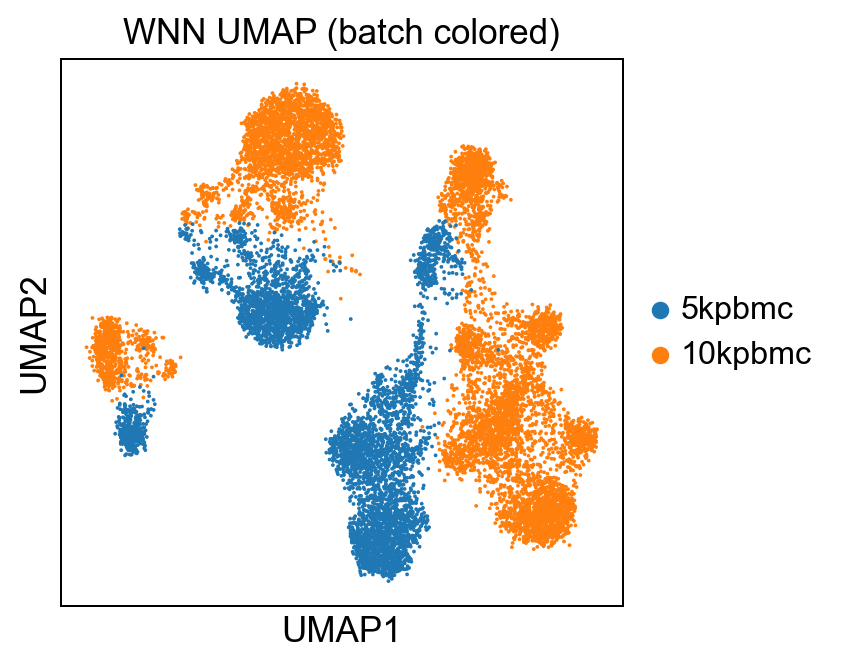

/var/folders/bd/djhgjhzs6rx_1ffvlb2ncd8c0000gn/T/ipykernel_13018/2106485792.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna, key_added='leiden_wnn', resolution=0.5, neighbors_key='neighbors_wnn')


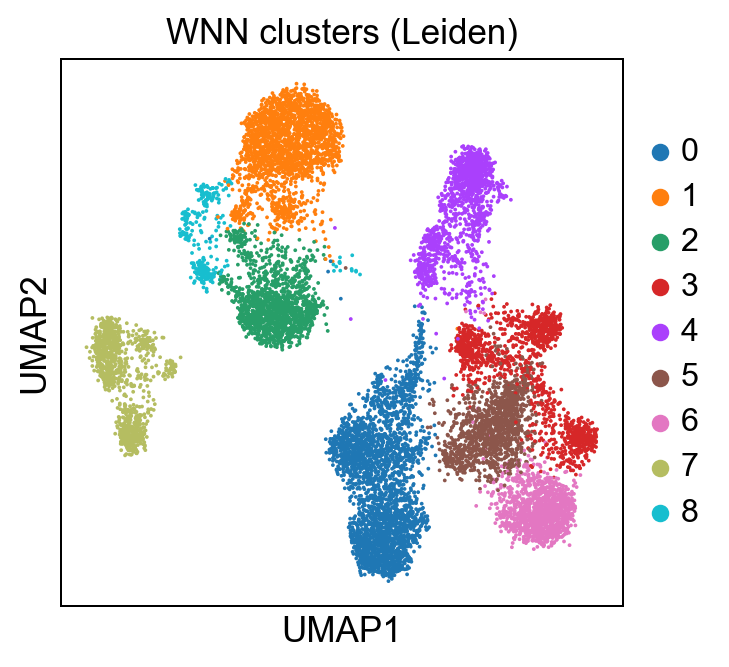

In [16]:
# compute UMAP from weighted neighbors
sc.tl.umap(rna, neighbors_key='neighbors_wnn')
sc.pl.umap(rna, color='batch', title='WNN UMAP (batch colored)')

# clustering using WNN graph
rna.obsp['connectivities'] = rna.obsp['connectivities_wnn']
sc.tl.leiden(rna, key_added='leiden_wnn', resolution=0.5, neighbors_key='neighbors_wnn')
sc.pl.umap(rna, color='leiden_wnn', title='WNN clusters (Leiden)')

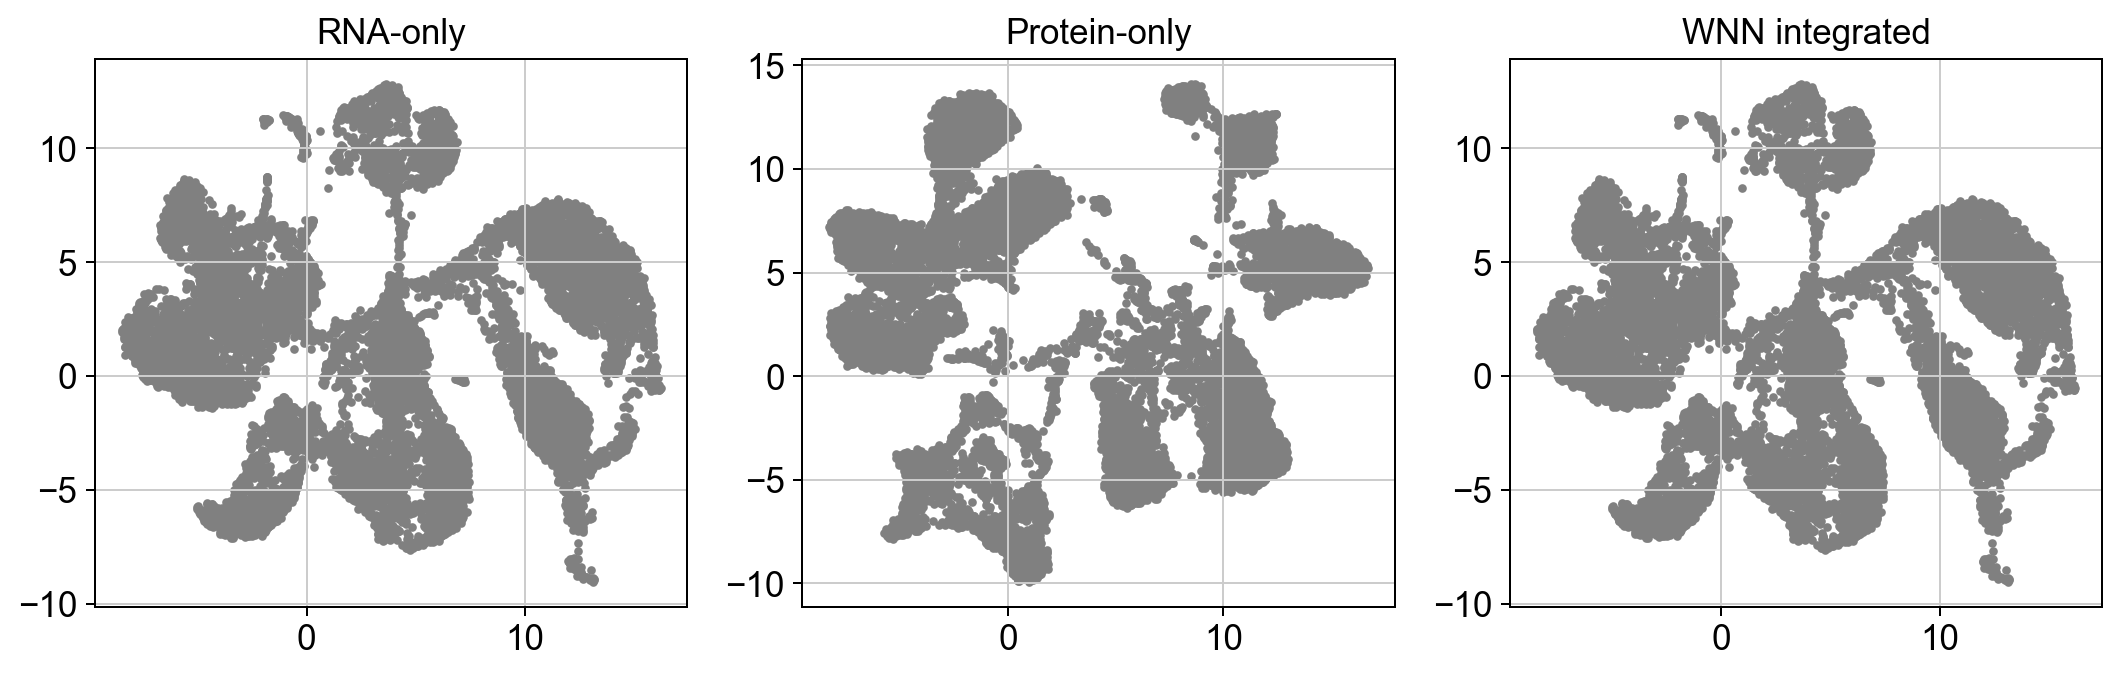

In [19]:
# RNA-only UMAP
sc.pp.neighbors(rna, use_rep='X_pca', n_neighbors=N_NEIGHBORS)   # builds rna.obsp['connectivities']
sc.tl.umap(rna)
rna_umap = rna.obsm['X_umap']

# explicitly define dictionary for protein neighbors
prot.uns['neighbors'] = {
    'connectivities_key': 'connectivities_prot',
    'distances_key': 'distances_prot',
    'params': {
        'n_neighbors': N_NEIGHBORS,
        'method': 'umap'
    }
}

# protein-only: reattach connectivities to prot and umap
prot.obsp['connectivities'] = prot.obsp['connectivities_prot']
prot.obsp['distances'] = prot.obsp['distances_prot']
sc.tl.umap(prot, neighbors_key='neighbors')
prot_umap = prot.obsm['X_umap']

# WNN UMAP we stored as 'X_umap' on rna when computing with `neighbors_key='neighbors_wnn'`
wnn_umap = rna.obsm['X_umap']

# quick plotting
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].scatter(rna_umap[:,0], rna_umap[:,1], s=6, c='gray'); axs[0].set_title('RNA-only')
axs[1].scatter(prot_umap[:,0], prot_umap[:,1], s=6, c='gray'); axs[1].set_title('Protein-only')
axs[2].scatter(wnn_umap[:,0], wnn_umap[:,1], s=6, c='gray'); axs[2].set_title('WNN integrated')
plt.tight_layout()


In [ ]:
# RNA-only clustering
sc.tl.leiden(rna, key_added='leiden_rna', resolution=0.5)  # using RNA-only neighbors

# rank genes in RNA-only and WNN clusters
sc.tl.rank_genes_groups(rna, groupby='leiden_rna', method='wilcoxon', key_added='rna_markers')
sc.tl.rank_genes_groups(rna, groupby='leiden_wnn', method='wilcoxon', key_added='wnn_rna_markers')

# get top N marker names for each cluster
def top_gene_set(adata, key, n=30):
    df = sc.get.rank_genes_groups_df(adata, group=None, key=key)
    top = df.groupby('group')['names'].apply(lambda s: list(s)[:n]).explode().tolist()
    return set(top)

rna_top = top_gene_set(rna, 'rna_markers', n=20)
wnn_top = top_gene_set(rna, 'wnn_rna_markers', n=20)
integration_only_genes = wnn_top - rna_top
print("Example integration-only genes:", list(integration_only_genes)[:20])


/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


Example integration-only genes: ['P2RX5', 'CHRM3-AS2', 'SPINT2', 'ALDH2', 'FCER1A', 'MEF2C', 'CRIP1']


/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


### Identification of integration-only genes

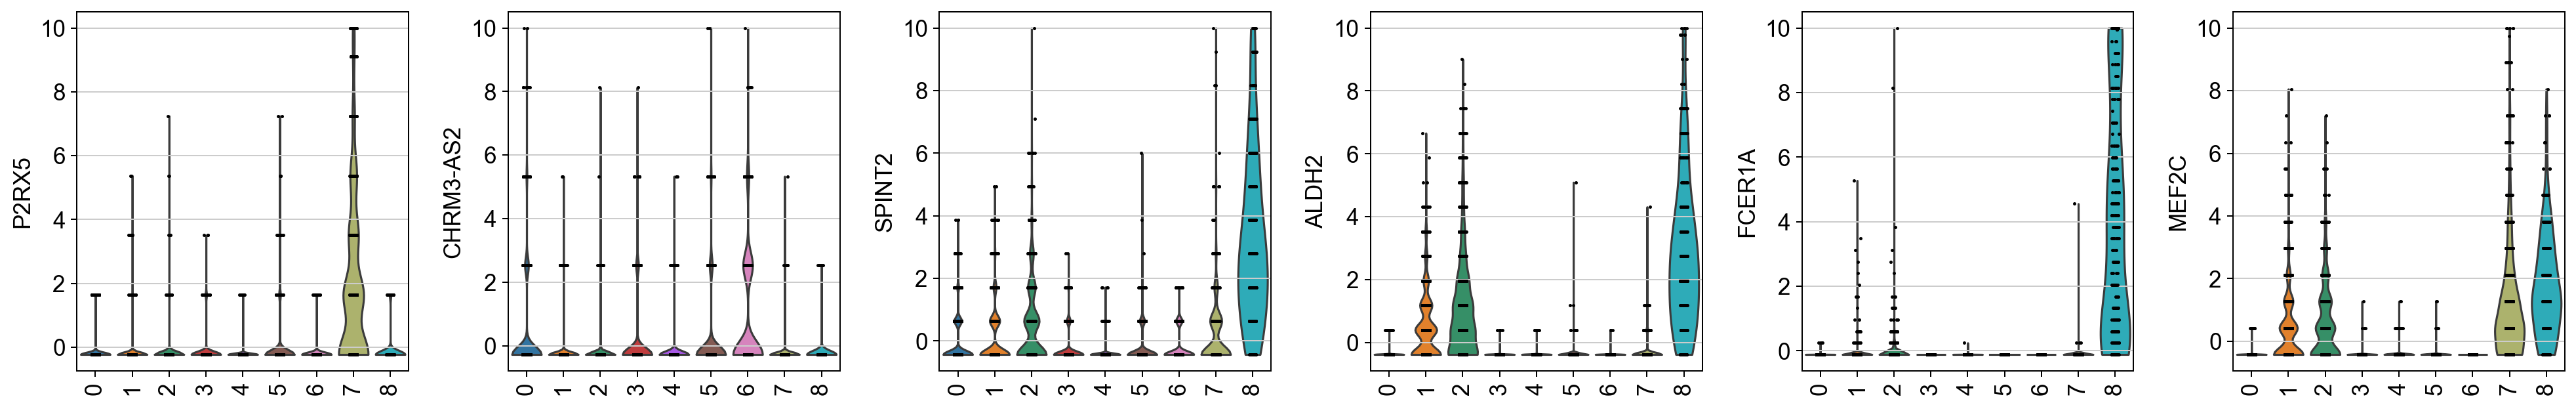

In [ ]:
# plot a gene that is integration-only
ex = list(integration_only_genes)[:6]
if ex:
    sc.pl.violin(rna, keys=ex, groupby='leiden_wnn', rotation=90, size=2)
